# **Práctica 3 - Parte 1**

###**Integrantes:**

- Mariana Fernández Prieto - C.C. 1001368196
- Isabella Quinchanegua Murillo - C.C. 1011087913

# **Resumen**

El electrocardiograma (ECG) es una señal biomédica que registra la actividad eléctrica del corazón, permitiendo observar procesos fisiológicos fundamentales como la despolarización y repolarización del tejido cardíaco. Esta señal está compuesta por diferentes componentes característicos: la onda P (despolarización auricular), el complejo QRS (despolarización ventricular) y la onda T (repolarización ventricular), los cuales presentan amplitudes y duraciones específicas [1]. El ECG es una señal de baja amplitud, que se puede ver afectada por distintos tipos de ruido, como interferencias musculares y variaciones de la línea base, por lo que suele ser filtrada para obtener información más clara [2].
#
En cuanto a la clasificación de las señales, estas pueden ser deterministas o estocásticas (aleatorias); las deterministas pueden describirse mediante una expresión matemática, lo que permite conocer su valor en cualquier instante de tiempo, mientras que las estocásticas presentan variabilidad aleatoria y se deben analizar estadísticamente. Las bioseñales, como el ECG, se consideran generalmente estocásticas debido a la variabilidad fisiológica y a la influencia de factores externos [3][4].
#
Las señales también pueden clasificarse según su estacionariedad: una señal es estacionaria si sus propiedades estadísticas, como la media y la varianza, permanecen constantes en el tiempo. En la práctica, las bioseñales no son estrictamente estacionarias, aunque pueden presentar este comportamiento en intervalos cortos [3][5].
#
En esta práctica se trabajó con señales ECG adquiridas a 1024 Hz, tanto sin filtrar como filtradas, con el fin de analizar su comportamiento en el tiempo. Se determinó la duración de la señal y se construyó el vector de tiempo, se compararon gráficamente las señales para evaluar el efecto del filtrado, y se seleccionaron ciclos cardíacos sobre los cuales se calcularon parámetros como la media, el valor RMS, la varianza y la desviación estándar. Posteriormente, se extrajeron múltiples ciclos para analizar su comportamiento estadístico y evaluar la estacionariedad mediante la comparación de sus características gráficas y estadísticas, así como mediante pruebas estadísticas como la t de Student, Mann-Whitney y Dickey-Fuller, concluyendo que la señal es estacionaria.
&nbsp;


In [ ]:
#Importación de librerías

import scipy.io as sio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.tsa.stattools import adfuller

### **1. Implemente una función que permita calcular el valor cuadrático medio (RMS) de una señal.**

A partir de la fórmula para el cálculo de RMS, se planteó la siguiente función:

In [ ]:
# Función para calcular el valor RMS
def RMS(senal):
  N = len(senal)
  RMS = ((1/N)*(np.sum(senal**2)))**0.5 #Fórmula guía
  return RMS

### **2. A partir de la información suministrada en el archivo signals.mat, determine el tiempo de duración de las señales, cree un vector de tiempo.**  

In [ ]:
datos = sio.loadmat('signals.mat') # Carga de datos al código

print((datos))

{'__header__': b'MATLAB 5.0 MAT-file, Platform: GLNXA64, Created on: Mon Apr 20 15:20:29 2015', '__version__': '1.0', '__globals__': [], 'Fs': array([[1024]], dtype=uint16), 'ECG_asRecording': array([[3904.31689453, 3939.203125  , 3976.00683594, ..., 4366.41064453,
        4365.31103516, 4370.91796875]]), 'ECG_filtered': array([[ 8.87103896e-03,  5.62737497e+01,  8.57077127e+01, ...,
        -1.20952610e+02, -1.31734356e+02, -1.32898021e+02]]), 'EMG_filtered1': array([[ 17.65905117,  19.41391578,  18.89666666, ..., 242.49414224,
        220.4135886 , 151.5810508 ]]), 'EMG_filtered2': array([[  21.1780547 ,  -79.82418538, -133.65960989, ..., -384.58994036,
        -539.9349533 , -772.65519631]]), 'EMG_asRecording1': array([[ 908.07531738,  903.17706299,  896.62982178, ..., 1433.91882324,
        1416.109375  , 1352.75012207]]), 'EMG_asRecording2': array([[-3109.97558594, -3231.01391602, -3302.34960938, ...,
        -3791.24267578, -3924.6550293 , -4109.94433594]])}


In [ ]:
ecg = datos['ECG_asRecording'][0] # Datos señal sin filtrar
t = np.arange(0,len(ecg)*(1/1024),(1/1024)) # Vector de tiempo
print(t)

[0.00000000e+00 9.76562500e-04 1.95312500e-03 ... 2.99970703e+01
 2.99980469e+01 2.99990234e+01]


A partir de los datos de la señal ECG, se construyó el vector de tiempo considerando la frecuencia de muestreo de 1024 Hz. Para esto, se definió un paso temporal de 1/1024 segundos entre cada muestra. Establecer correctamente este eje es un paso fundamental para poder identificar temporalmente las ondas del ciclo cardíaco y asegurar la precisión de los análisis posteriores en el dominio del tiempo.


### **3. Grafique la señal sin filtrar y filtrada, compárelas. Comente lo que observa, y describa cómo debe ser el comportamiento del filtro que se utilizó. Recuerde las frecuencias de interés de la señal ECG.**

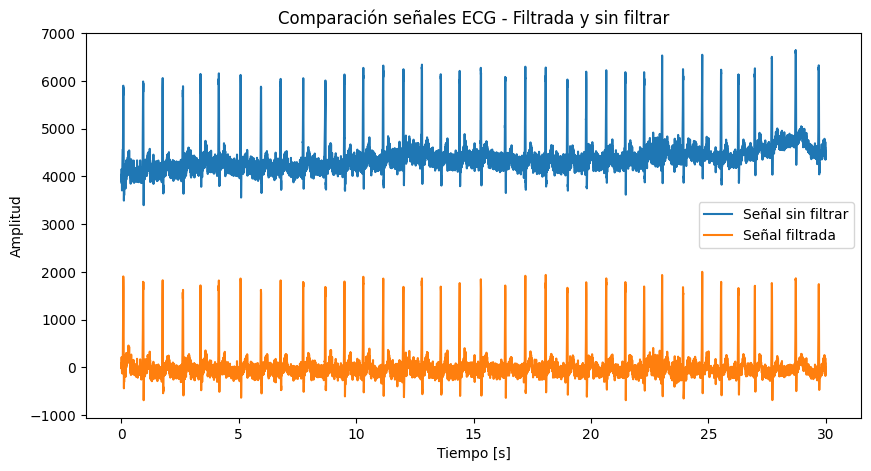

In [ ]:
ecg_fil = datos['ECG_filtered'][0] # Datos señal filtrada

# Gráfica señal sin filtrar y filtrada
plt.figure(figsize=(10,5))
plt.plot(t,ecg,label='Señal sin filtrar') # Señal sin filtrar
plt.plot(t,ecg_fil,label='Señal filtrada') # Señal filtrada
plt.title('Comparación señales ECG - Filtrada y sin filtrar')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.legend()

La comparación entre la señal original y la señal filtrada mostró mejoras significativas en la calidad de la señal tras el proceso de filtrado. La señal original presenta un valor promedio elevado, cercano a 4119, lo que indica la presencia de un desplazamiento del offset además presenta variaciones asociadas a ruido. Por otro lado, la señal filtrada muestra una reducción considerable de este offset, con un valor promedio cercano a 92.6, lo cual indica que el filtro aplicado elimina componentes de baja frecuencia no deseadas.

Adicionalmente, la señal filtrada presenta una mayor estabilidad y una mejor definición de los complejos cardíacos, lo que sugiere la aplicación de un filtro pasa banda que conserva las frecuencias de interés del ECG y atenúa tanto el ruido de alta frecuencia como las variaciones lentas. Por tanto, el filtrado no solo mejora la visualización de la señal, sino que también permite obtener resultados estadísticos más característicos de la actividad fisiológica.

### **4. Seleccione un ciclo cardiaco, grafique. Calcule el promedio, el valor RMS, la varianza y la desviación estándar del ciclo. Analice los resultados.**

Text(0, 0.5, 'Amplitud')

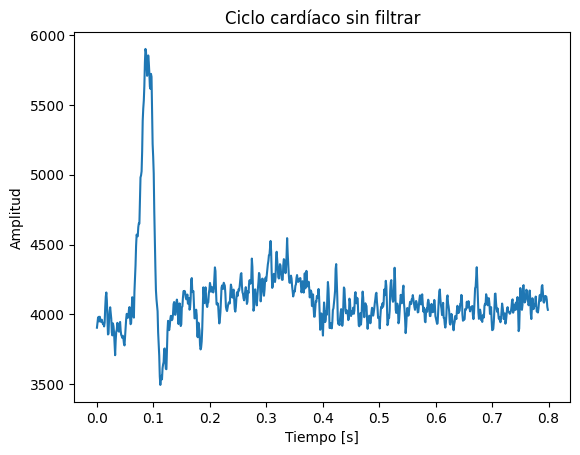

In [ ]:
ciclo = int(0.8*1024) # Definición de ciclo cardíaco. Duración de 0.8 segundos
d_ciclo = ecg[0:ciclo] # Selección de un ciclo cardíaco
t_ciclo = np.arange(len(d_ciclo)) / 1024 # Duración del ciclo cardíaco

# Gráfica ciclo sin filtrar
plt.plot(t_ciclo,d_ciclo)
plt.title('Ciclo cardíaco sin filtrar')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')

In [ ]:
# Medidas estadísticas un ciclo filtrado
print(f'Promedio: {np.mean(d_ciclo)}')
print(f'RMS: {RMS(d_ciclo)}')
print(f'Varianza: {np.var(d_ciclo)}')
print(f'Desviación estándar: {np.std(d_ciclo)}')

Promedio: 4119.020062457074
RMS: 4129.509640664121
Varianza: 86523.59741404252
Desviación estándar: 294.1489374688315


Al analizar un ciclo cardíaco de la señal sin procesar, se obtuvieron valores de 4119.02 para el promedio, 4129.51 para el RMS, 86523.60 en la varianza y 294.15 en la desviación estándar. Estos resultados evidencian el predominio del desplazamiento del offset, lo cual se deduce de la proximidad entre el promedio y el RMS. Asimismo, la alta varianza y desviación estándar indican que los datos presentan una dispersión significativa. Debido a que estas métricas están dominadas por el offset y el ruido, no representan de forma adecuada el comportamiento real de la señal cardiaca. Por este motivo, el análisis directo sobre la señal original resulta insuficiente para obtener conclusiones fisiológicas válidas.

### **5. Repita el procedimiento anterior la señal filtrada, compare con los resultados obtenidos en el ítem anterior.**  

Text(0, 0.5, 'Amplitud')

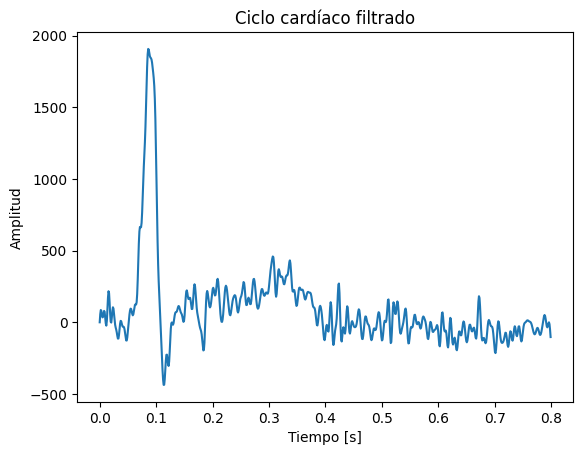

In [ ]:
d_ciclo_fil = ecg_fil[0:ciclo] # 1 ciclo cardiaco, señal filtrada

# Gráfica ciclo filtrado
plt.plot(t_ciclo, d_ciclo_fil)
plt.title('Ciclo cardíaco filtrado')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')

In [ ]:
# Medidas estadísticas un ciclo filtrado
print(f'Promedio: {np.mean(d_ciclo_fil)}')
print(f'RMS: {RMS(d_ciclo_fil)}')
print(f'Varianza: {np.var(d_ciclo_fil)}')
print(f'Desviación estándar: {np.std(d_ciclo_fil)}')

Promedio: 92.61398178971956
RMS: 325.08790538716397
Varianza: 97104.79660606716
Desviación estándar: 311.61642544331187


Al realizar el mismo análisis sobre la señal filtrada, se obtuvo un valor promedio de 92.61, un RMS de 325.09, una varianza de 97104.80 y una desviación estándar de 311.62. La reducción significativa del promedio confirma la eliminación del offset, permitiendo centrar la señal y mejorar su interpretación.

Aunque se observa un incremento en la varianza y la desviación estándar respecto a la señal sin filtrar, este comportamiento es esperado, ya que al eliminar el componente constante, las variaciones propias del ciclo cardíaco adquieren mayor relevancia en el cálculo estadístico. En este sentido, las métricas obtenidas a partir de la señal filtrada reflejan de manera más precisa la actividad fisiológica del corazón.

### **6. Extraiga 15 ciclos de la señal filtrada, y para cada ciclo calcule el valor promedio y la varianza, grafique cada ciclo, y analice (gráfica y estadísticamente). ¿Se puede considerar que la señal es estacionaria?**

Text(0, 0.5, 'Amplitud')

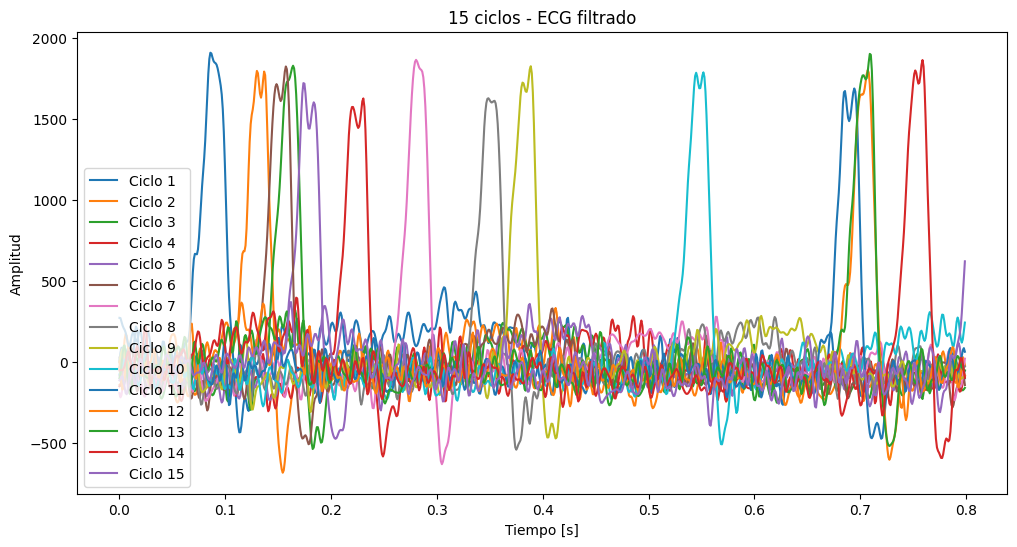

In [ ]:
ciclos_15 = [] # Lista para almacenar cada ciclo por separado

for i in range(15): # for para seleccionar los 15 ciclos
    inicio = i * ciclo # Inicio del ciclo
    fin = inicio + ciclo # Fin del ciclo
    ciclos_15.append(ecg_fil[inicio:fin]) # Agregar ciclos (señal filtrada) a la lista

ciclos_15 = np.array(ciclos_15) #Convertir la lista a una matriz

# Gráfica de los 15 ciclos cardiacos
plt.figure(figsize=(12,6))
for i in range(15):
    plt.plot(t_ciclo, ciclos_15[i], label=f'Ciclo {i+1}') # for para gráficar cada ciclo
plt.legend(loc='lower left')
plt.title("15 ciclos - ECG filtrado")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")

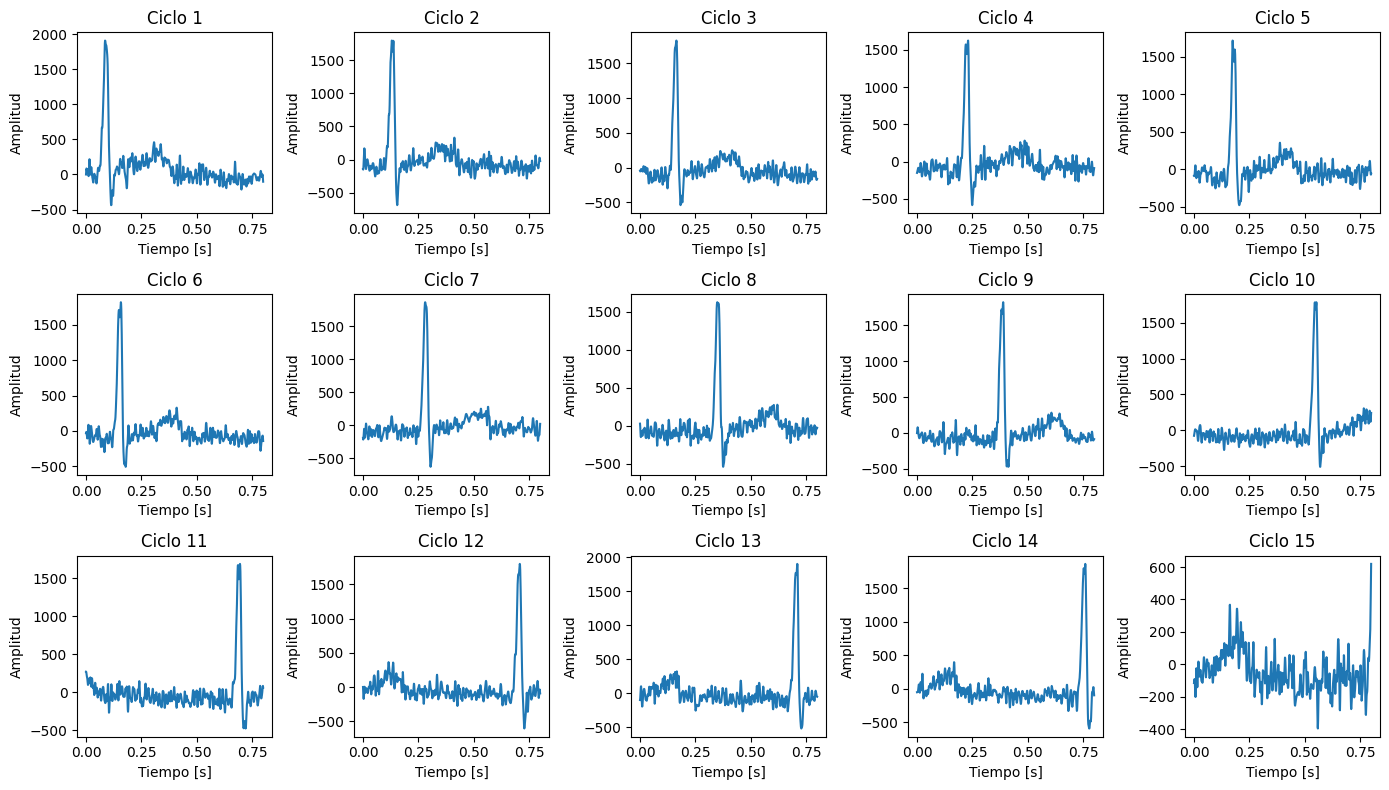

In [ ]:
# Gráfica de cada ciclo por separado (mejor visualización)
fig, axs = plt.subplots(3, 5, figsize=(14, 8))  # 5 filas, 3 columnas
axs = axs.flatten()  # convertir a vector para iterar fácil

for i in range(15):
    axs[i].plot(t_ciclo, ciclos_15[i]) # Gráfica de un ciclo
    axs[i].set_title(f'Ciclo {i+1}')
    axs[i].set_xlabel('Tiempo [s]')
    axs[i].set_ylabel('Amplitud')

plt.tight_layout()

In [ ]:
# Cálculo de medias y varianzas de cada ciclo
medias = np.mean(ciclos_15, axis=1)
varianzas = np.var(ciclos_15, axis=1)

# Datos tabulados para mejor visualización
st_15c = pd.DataFrame({"Ciclo": np.arange(1, len(medias) + 1), "Media": medias,
    "Varianza": varianzas})

print(st_15c)

    Ciclo      Media      Varianza
0       1  92.613982  97104.796606
1       2  -5.759178  90783.766936
2       3  -5.569453  86514.425800
3       4  -9.398469  76845.820850
4       5  16.508281  77757.267582
5       6  -0.756074  88914.654952
6       7   9.959618  90163.126798
7       8   1.334138  74941.423090
8       9  12.906039  85844.720934
9      10  -3.598515  85788.141585
10     11 -10.872479  75328.282087
11     12  -6.044178  83294.080265
12     13  13.014388  91326.911390
13     14  -2.227201  94258.071794
14     15 -48.452460  14027.071224


Para este análisis se extrajeron 15 ciclos cardíacos de la señal filtrada y se graficaron para observar su comportamiento. A nivel gráfico, se puede notar que los ciclos tienen una forma bastante similar, especialmente en el complejo QRS, lo que indica que la estructura general del ECG se mantiene a lo largo del tiempo. Sin embargo, también se observan pequeñas diferencias en la amplitud y en algunos detalles de la forma entre un ciclo y otro, lo cual es normal en este tipo de señales fisiológicas.

Desde el punto de vista estadístico, se calcularon el promedio y la varianza para cada ciclo. Se encontró que estos valores cambian entre ciclos, es decir, no son exactamente iguales. Sin embargo, estas diferencias no presentan un comportamiento creciente o decreciente definido, sino que corresponden a oscilaciones alrededor del promedio.  Esto indica que hay variabilidad, pero no un cambio progresivo en el comportamiento de la señal.

Teniendo en cuenta tanto la gráfica como los resultados estadísticos, se puede decir que la señal presenta variaciones entre ciclos, pero estas corresponden a cambios normales y no a una modificación estructural de la señal. Es decir, la señal no es completamente constante en cada segmento, pero sí mantiene un comportamiento general estable.

Por lo tanto, se concluye que la señal puede considerarse estacionaria en términos globales, ya que no presenta tendencias en el tiempo. Sin embargo, también presenta variabilidad local entre ciclos, lo cual es esperado en señales fisiológicas como el ECG.

### **7. Realice dos veces comparaciones entre dos ciclos cualquiera utilizando una prueba t. Determine estadísticamente si existe diferencia estadística entre los ciclos.**


##### **- Comparación ciclos 3 y 12:**

In [ ]:
# Ciclos a comparar
c1 = ciclos_15[2] # Ciclo 3
c2 = ciclos_15[11] # Ciclo 12

# Comprobación de supuestos de la prueba t:
print('Supuestos de la prueba t:')

# Normalizar (necesario para comparar con N(0,1) en la prueba de Kolmogorov-Smirnov)
c1_norm = (c1 - np.mean(c1)) / np.std(c1)
c2_norm = (c2 - np.mean(c2)) / np.std(c2)

# 1. Prueba de Kolmogorov-Smirnov para evaluar normalidad
_, p_ks1 = stats.kstest(c1_norm, 'norm')
_, p_ks2 = stats.kstest(c2_norm, 'norm')

print('\n1. Normalidad:')
print(f"K-S ciclo 3, valor-p = {p_ks1:.4f}")
print(f"K-S ciclo 12, valor-p = {p_ks2:.4f}")

# 2. Correlación de Pearson para evaluar independencia
corr, p_corr = stats.pearsonr(c1, c2)

print('\n2. Independencia:')
print(f"Correlación: {corr:.4f}")
print(f"valor-p: {p_corr:.4f}")

# 3. Prueba de Levene para evaluar homocedasticidad
_, p_levene = stats.levene(c1, c2)

print('\n3. Homocedasticidad:')
print(f"Levene valor-p = {p_levene:.4f}\n")

# Prueba para comprobar estacionariedad:
print('\nPrueba estacionariedad:')

# Prueba t
_, p_t = stats.ttest_ind(c1, c2)
print(f"\nPrueba t valor-p = {p_t:.4f}")

# Prueba de Mann-Whitney (para datos que no siguen una distribución normal)
_, p_mw = stats.mannwhitneyu(c1, c2)
print(f"Mann-Whitney valor-p = {p_mw:.4f}")

Supuestos de la prueba t:

1. Normalidad:
K-S ciclo 3, valor-p = 0.0000
K-S ciclo 12, valor-p = 0.0000

2. Independencia:
Correlación: 0.0311
valor-p: 0.3734

3. Homocedasticidad:
Levene valor-p = 0.9535


Prueba estacionariedad:

Prueba t valor-p = 0.9737
Mann-Whitney valor-p = 0.7909


##### **- Comparación ciclos 6 y 9:**

In [ ]:
# Ciclos a comparar
c3 = ciclos_15[5] # Ciclo 6
c4 = ciclos_15[8] # Ciclo 9

# Comprobación de supuestos de la prueba t:
print('Supuestos de la prueba t:')

# Normalizar (necesario para comparar con N(0,1) en la prueba de Kolmogorov-Smirnov)
c3_norm = (c3 - np.mean(c3)) / np.std(c3)
c4_norm = (c4 - np.mean(c4)) / np.std(c4)

# 1. Prueba de Kolmogorov-Smirnov para evaluar normalidad
_, p_ks3 = stats.kstest(c3_norm, 'norm')
_, p_ks4 = stats.kstest(c4_norm, 'norm')

print('\n1. Normalidad:')
print(f"K-S ciclo 6, valor-p = {p_ks3:.4f}")
print(f"K-S ciclo 9, valor-p = {p_ks4:.4f}")

# 2. Correlación de Pearson para evaluar independencia
corr2, p_corr2 = stats.pearsonr(c3, c4)

print('\n2. Independencia:')
print(f"Correlación: {corr2:.4f}")
print(f"valor-p: {p_corr2:.4f}")

# 3. Prueba de Levene para evaluar homocedasticidad
_, p_levene2 = stats.levene(c3, c4)

print('\n3. Homocedasticidad:')
print(f"Levene valor-p = {p_levene2:.4f}\n")

# Prueba para comprobar estacionariedad:
print('\nPrueba estacionariedad:')

# Prueba t

_, p_t2 = stats.ttest_ind(c3, c4)
print(f"\nPrueba t valor-p = {p_t2:.4f}")

# Prueba de Mann-Whitney (para datos que no siguen una distribución normal)

_, p_mw2 = stats.mannwhitneyu(c3, c4)
print(f"Mann-Whitney valor-p = {p_mw2:.4f}")

Supuestos de la prueba t:

1. Normalidad:
K-S ciclo 6, valor-p = 0.0000
K-S ciclo 9, valor-p = 0.0000

2. Independencia:
Correlación: 0.0413
valor-p: 0.2380

3. Homocedasticidad:
Levene valor-p = 0.7016


Prueba estacionariedad:

Prueba t valor-p = 0.3501
Mann-Whitney valor-p = 0.0038


Para evaluar si existen diferencias entre ciclos cardíacos, se realizaron dos comparaciones entre pares de ciclos utilizando pruebas estadísticas. Antes de aplicar la prueba t, se verificaron los supuestos necesarios. En particular, se utilizó la prueba de Kolmogorov-Smirnov para evaluar la normalidad, ya que permite comparar los datos con una distribución normal y así determinar si es válido aplicar pruebas paramétricas.

En la primera comparación (ciclos 3 y 12), la prueba de normalidad arrojó valores de p = 0.0000 para ambos ciclos, lo que indica que los datos no siguen una distribución normal. A pesar de esto, se continuó con el análisis. La prueba de Levene dio un p = 0.9535, lo que sugiere que las varianzas son iguales. Al aplicar la prueba t, se obtuvo un p-value = 0.9737, indicando que no hay diferencias estadísticamente significativas entre los ciclos. Este resultado también se confirmó con la prueba de Mann-Whitney (p = 0.7909).

En la segunda comparación (ciclos 6 y 9), nuevamente la prueba de normalidad indicó que los datos no son normales (p = 0.0000). La prueba de Levene dio un p = 0.7016, por lo que se pueden asumir varianzas iguales. La prueba t arrojó un p-value = 0.3501, lo que sugiere que no hay diferencias significativas. Sin embargo, la prueba de Mann-Whitney dio un p-value = 0.0038, indicando que sí existen diferencias significativas en este caso.  En general, los resultados muestran que no hay un comportamiento completamente uniforme entre todos los ciclos, ya que en algunos casos sí se presentan diferencias. Sin embargo, estas diferencias no siguen un patrón definido ni indican un cambio progresivo en el tiempo. Esto sugiere que la señal mantiene un comportamiento relativamente estable en sus propiedades estadísticas, aunque con variaciones locales, lo cual es consistente con el comportamiento esperado de una señal aproximadamente estacionaria.

### **8. Compruebe los resultados anteriores aplicando una prueba de Dickey-Fuller a la señal (Estacionariedad)**

In [ ]:
# Prueba de Dickey-Fuller
resultado = adfuller(ecg_fil)

print("Estadístico ADF:", resultado[0])
print(f"valor-p: {resultado[1]:.4f}")

if resultado[1] < 0.05:
    print("La señal es estacionaria")
else:
    print("La señal no es estacionaria")

Estadístico ADF: -24.134106752075187
valor-p: 0.0000
La señal es estacionaria


Para evaluar formalmente la estacionariedad de la señal, se aplicó la prueba de Dickey-Fuller aumentada (ADF).  En este caso, la prueba arrojó un p-value = 0.0000, lo que es menor que el nivel de significancia (α = 0.05). Por lo tanto, se rechaza la hipótesis nula, que establece que la señal no es estacionaria [6]. Esto indica que la señal sí puede considerarse estacionaria.

Este resultado es coherente con los análisis realizados previamente. Aunque en la comparación entre ciclos se observaron algunas variaciones y diferencias puntuales, estas no seguían un patrón definido ni mostraban cambios progresivos en el tiempo. Es decir, la señal presenta fluctuaciones locales, pero mantiene un comportamiento global estable en términos de sus propiedades estadísticas.

En conclusión, la prueba de Dickey-Fuller confirma que la señal es estacionaria, lo cual es consistente con lo observado tanto en las gráficas como en el análisis estadístico de los ciclos cardíacos.

# **Conclusiones:**

*   El proceso de filtrado aplicado a la señal ECG permitió reducir el ruido presente sin alterar sus características principales, facilitando la identificación de los ciclos cardíacos y mejorando la calidad del análisis posterior.

*   El análisis de múltiples ciclos cardíacos evidenció que, aunque existen variaciones en la amplitud y forma entre ciclos, estas no siguen un patrón definido, lo que indica que la señal mantiene un comportamiento global estable con variaciones locales propias de señales fisiológicas.

*   A partir de las pruebas estadísticas y el análisis de estacionariedad, se concluye que la señal puede considerarse estacionaria, ya que no presenta cambios sistemáticos en sus propiedades a lo largo del tiempo, lo cual es consistente con los resultados obtenidos en la prueba de Dickey-Fuller.





# **Referencias**

[1] Componentes e intervalos en un electrocardiograma (ECG) | Cigna. (s. f.). https://www.cigna.com/es-us/knowledge-center/hw/componentes-e-intervalos-en-un-electrocardiograma-zm2308

[2] Chicco, D., Karaiskou, A., & De Vos, M. (2024). Ten quick tips for electrocardiogram (ECG) signal processing. PeerJ Computer Science, 10, e2295. https://doi.org/10.7717/peerj-cs.2295

[3] Guía de laboratorio práctica 3 - Análisis estadístico de señales

[4] Signals classification. (s. f.). https://www.tutorialspoint.com/signals_and_systems/signals_classification.htm

[5] RPUBS - Series de tiempo: Estacionariedad. (s. f.). https://rpubs.com/Arthurus/492144?ref=ciberseguridad.blog

[6] GeeksforGeeks. (2025, 23 julio). Augmented DickeyFuller (ADF). GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/augmented-dickey-fuller-adf/